# Who Writes What? Mapping the Interaction Between Author Gender and Media Specialization

## Data Description & Statistical Modeling Notebook

**Authors:** Bouzid Nélia & Delerue Eloïse

**E-mails:** nelia.bouzid@psl.eu & eloise.delerue@psl.eu

**Laboratory:** PSL University

**Date:** January 25th, 2026

## 1. Library & Data Import


### 1.1. Library Import

In [ ]:
# Data Manipulation & Processing
import pandas as pd
import csv

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical Modeling
import statsmodels.formula.api as smf

In [ ]:
# Set visual theme for Seaborn/Matplotlib
sns.set_theme(style="whitegrid")

### 1.2. Data Import

In [ ]:
# To display the full data
pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)

In [ ]:
# Increase the field reading limit to the maximum authorized by the system to avoid reading errors in the articles
# This step is necessary for topic modeling on the entire articles
csv.field_size_limit(10000000)

10000000

In [ ]:
# Import and read the dataset
df = pd.read_csv('final_csv_factiva.csv', sep=",", engine='python', on_bad_lines="warn")
display(df)

,Unnamed: 0,unnamed: 0,doc_id,type_of_reference,title,authors,date,journal_name,source_id,language,evenement,text,id,n_articles,type,prenom_extracted,genre_assigned,clean_text,clean_text_bigrams,dominant_topic,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15,topic_16,topic_17,topic_18,topic_19,topic_20,topic_21,topic_22,topic_23,topic_24,topic_25,topic_26,topic_27,topic_28,topic_29,topic_30,topic_31,topic_32,topic_33,topic_34,topic_35,topic_36,Digital_BigTech_Data,Media_Economics,Marketing_Agencies,Consumer_Goods,Finance_RealEstate,Public_Law_Tenders,Politics_Urban,Regul_Ads_Ethics,Solo_Gender_Diversity,Solo_Fast_Fashion,Solo_Sport,Solo_Tourism,Solo_Automotive,Solo_Specific_Case,Solo_General
0,0,2,2,EJOUR,L’ abonnement avec publicité de Netflix c...,marie debauche,2024,La Libre Belgique,LBQ,Français,abonnement_netflix,Plus de 40 millions d’utilisateurs ont déjà so...,154,19,Générale,marie,F,million souscrire formule proposer formule abo...,million souscrire formule proposer formule_abo...,35,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
1,1,3,3,EJOUR,NETFLIX ET LES AUTRES,thierry wojciak,2024,CB News,NEWCB,Français,abonnement_netflix,"EN LANÇANT SES OFFRES AVEC PUBLICITÉ , L'INCON...",38,189,Pro,thierry,M,lancer offre fois voix concurrent mondiau chan...,lancer offre fois voix concurrent mondiau chan...,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
2,2,4,4,EJOUR,"Netflix , Disney+ : tout savoir sur les abonne...",sylvain rolland,2022,La Tribune,TRDS,Français,abonnement_netflix,Les deux champions du streaming vidéo sur abon...,165,38,Générale,sylvain,M,champion streaming vidéo abonnemer svod lancer...,champion streaming_vidéo abonnemer svod lancer...,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,3,5,5,EJOUR,"La publicité sur Netflix , un virage dans l...",david pargamin,2022,Challenges.fr,CHALCOM,Français,abonnement_netflix,Les futures offres de Netflix pourraient inclu...,47,169,Ecofinance,david,M,future offre pouvoir inclure an impensable pla...,future offre pouvoir inclure an impensable pla...,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,4,8,8,EJOUR,Netflix s'effondre en Bourse face à l'effrite...,hortense goulard; correspondante à san francisco,2022,Les Echos,ECHOS,Français,abonnement_netflix,La plateforme de vidéo à la demande a perdu 20...,232,65,Ecofinance,hortense,F,plateforme vidéo demande perdre abonner mois f...,plateforme vidéo_demande perdre abonner mois f...,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3241,3241,5685,5685,EJOUR,Une fillette voilée dans une publicité : G...,guillaume poingt,2018,Le Figaro Premium,FIGPRE,Français,voile,VIDÉO - La marque américaine de vêtements a mi...,184,63,Générale,guillaume,M,vidéo marque américaine vêtement mettre scène ...,vidéo marque américaine vêtement mettre_scène ...,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3242,3242,5688,5688,EJOUR,« Je peux gassar sans compter » : le marketing...,arthur de boutiny,2014,Rue89,RUEFR,Français,voile,"C’est une publicité réussie, selon Jean-Christ...",287,4,Générale,arthur,M,réussir entrepreneur marketing femme souriant ...,réussir entrepreneur marketing femme souriant ...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3243,3243,5691,5691,EJOUR,«Quand une entreprise cède à 

## 2. Data Description

In [ ]:
# topics mapping
topics = ['Digital_BigTech_Data', 'Media_Economics', 'Marketing_Agencies', 'Consumer_Goods', 'Finance_RealEstate', 'Public_Law_Tenders', 'Regul_Ads_Ethics']

/tmp/ipython-input-3112814461.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 0], data=df, x='genre_assigned', palette=palette_genre)
/tmp/ipython-input-3112814461.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0, 1], data=df, x='type', palette="viridis", order=df['type'].value_counts().index)
/tmp/ipython-input-3112814461.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 1], data=df_counts, x='Total', y='Pôle', palette="viridis")


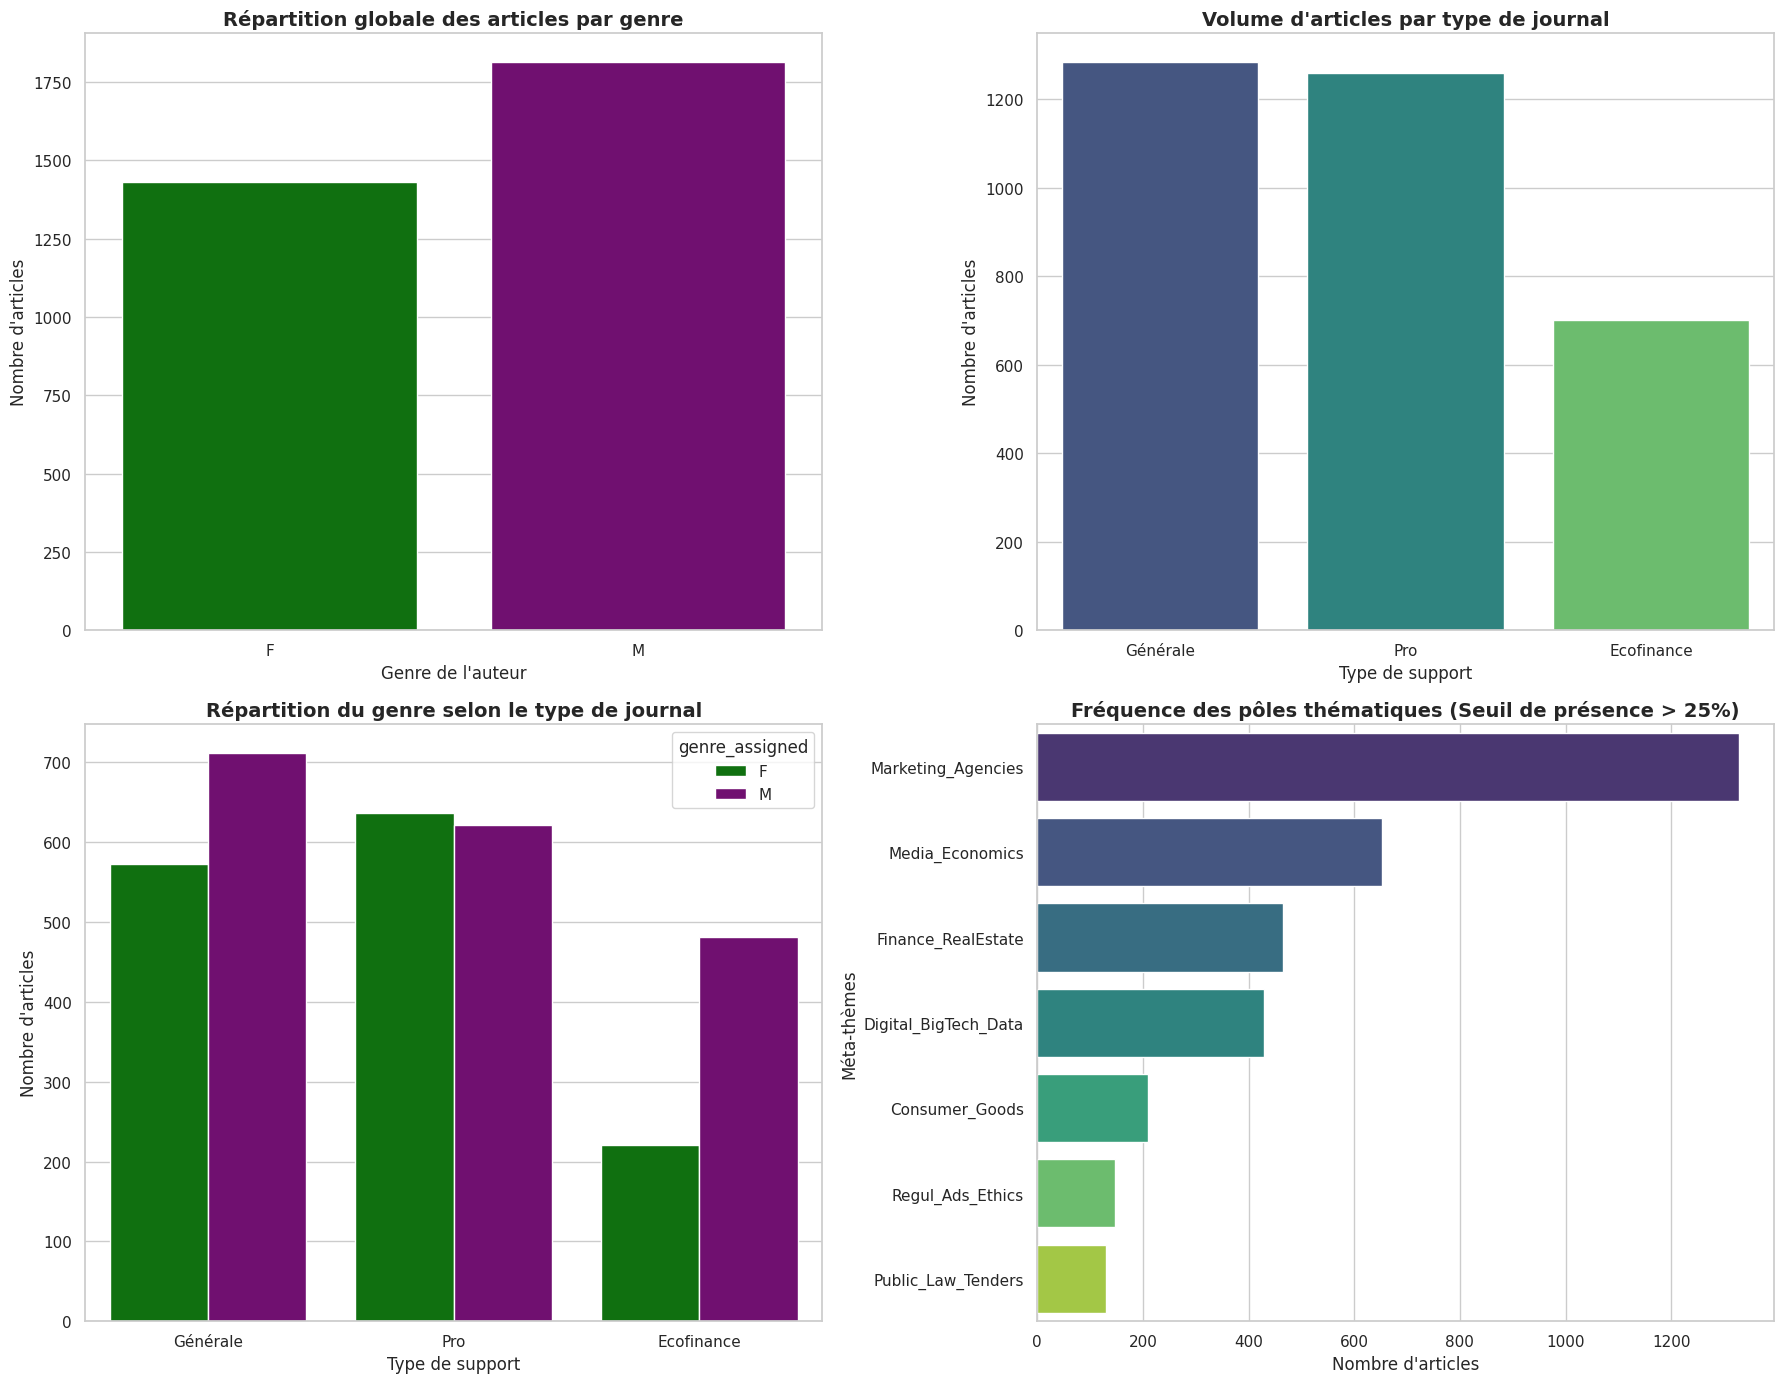

In [ ]:
# Set the visual style and color mapping
palette_genre = {'F': 'green', 'M': 'purple'}

# Initialize a global figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Barplot: Total article count by GENDER
sns.countplot(ax=axes[0, 0], data=df, x='genre_assigned', palette=palette_genre)
axes[0, 0].set_title("Overall Distribution of Articles by Gender", fontsize=18, fontweight='bold')
axes[0, 0].set_xlabel("Author Gender")
axes[0, 0].set_ylabel("Number of Articles")

# Barplot: Total article count by JOURNAL TYPE
sns.countplot(ax=axes[0, 1], data=df, x='type', palette="viridis", order=df['type'].value_counts().index)
axes[0, 1].set_title("Article Volume per Journal Type", fontsize=18, fontweight='bold')
axes[0, 1].set_xlabel("Journal Category")
axes[0, 1].set_ylabel("Number of Articles")

# Crosstab Barplot: JOURNAL TYPE & GENDER
sns.countplot(ax=axes[1, 0], data=df, x='type', hue='genre_assigned', palette=palette_genre)
axes[1, 0].set_title("Gender Distribution Across Journal Categories", fontsize=18, fontweight='bold')
axes[1, 0].set_xlabel("Journal Category")
axes[1, 0].set_ylabel("Number of Articles")

# Barplot: TOP SUPER-TOPICS (Prevalence above 25% threshold)
# Calculate frequencies per topic group
# Since these are binary (0/1), the sum represents the total number of articles per topic
counts = df[topics].sum().sort_values(ascending=False)

# Convert to DataFrame for Seaborn compatibility
df_counts = counts.reset_index()
df_counts.columns = ['Topic Group', 'Total']

sns.barplot(ax=axes[1, 1], data=df_counts, x='Total', y='Topic Group', palette="viridis")
axes[1, 1].set_title(f"Prevalence of Thematic Clusters (Presence Threshold > 25%)", fontsize=18, fontweight='bold')
axes[1, 1].set_xlabel("Number of Articles")
axes[1, 1].set_ylabel("Meta-themes")

# Adjust layout for clarity and export to high-resolution PDF
plt.tight_layout()
plt.savefig("corpus_descriptive_analysis.pdf", dpi=150)
plt.show()

In [ ]:
# Prepare translations and categorical mapping
translations = {
    'Digital_BigTech_Data': 'Numérique, Big Tech et Données',
    'Media_Economics': 'Économie des Médias',
    'Marketing_Agencies': 'Marketing et Agences',
    'Consumer_Goods': 'Consommation et Retail',
    'Finance_RealEstate': 'Finance et Corporate',
    'Public_Law_Tenders': 'Droit et Marchés Publics',
    'Regul_Ads_Ethics': 'Régulation Publicitaire et Éthique'
}

# Define gender labels and color palette for plots (Legend and Axes)
genre_map = {'F': 'Femme', 'M': 'Homme'}
palette_genre = {'Femme': 'green', 'Homme': 'purple'}

# Create a copy of the dataset to avoid modifying the original DataFrame
df_plot = df.copy()
df_plot['Genre'] = df_plot['genre_assigned'].map(genre_map)

# Configure visual style (Using whitegrid for an academic presentation)
sns.set_theme(style="whitegrid")

/tmp/ipython-input-3850125568.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes1[0], data=df_plot, x='Genre', palette=palette_genre)
/tmp/ipython-input-3850125568.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes1[1], data=df_plot, x='type', palette="viridis", order=df_plot['type'].value_counts().index)


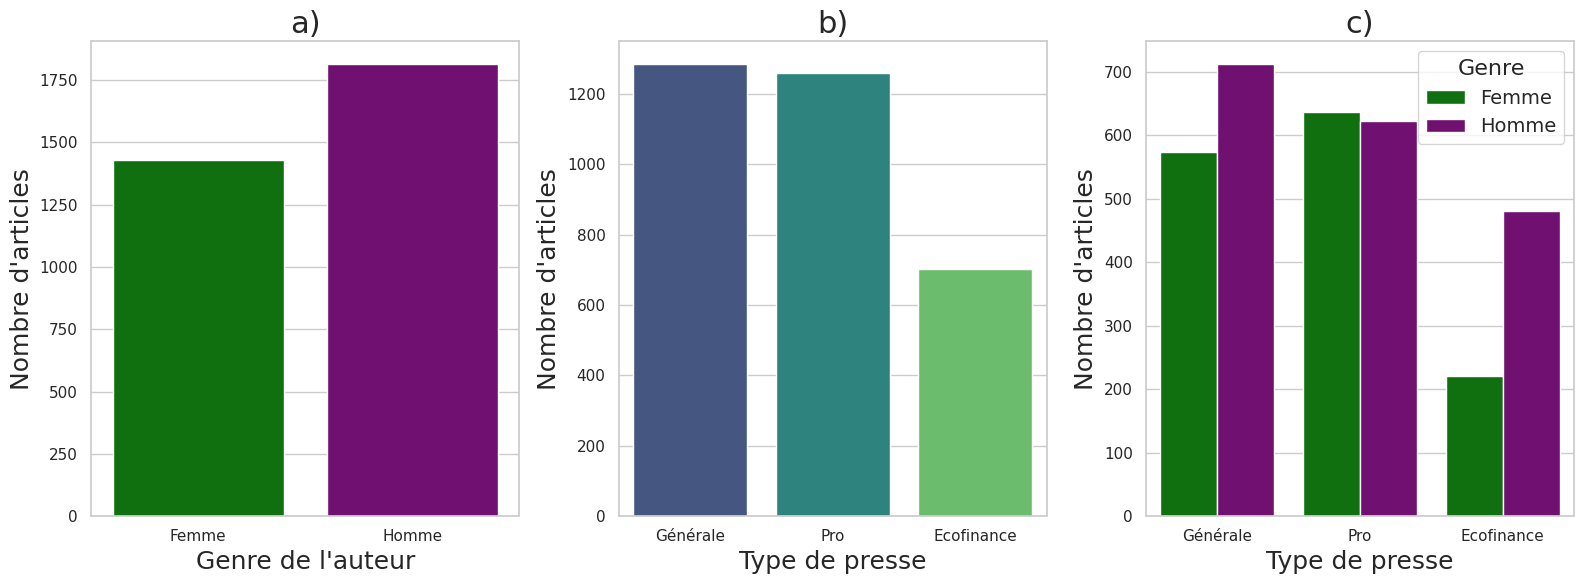

In [ ]:
# PLOT 1: GENDER AND MEDIA OUTLETS (Output File 1)
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 6))

# a) Distribution of articles by Author Gender
sns.countplot(ax=axes1[0], data=df_plot, x='Genre', palette=palette_genre)
axes1[0].set_xlabel("Author Gender", fontsize=18)
axes1[0].set_ylabel("Number of Articles", fontsize=18)
axes1[0].set_title("a)", fontsize=22)

# b) Distribution of articles by Journal Type
# Articles are ordered by frequency for better readability
sns.countplot(ax=axes1[1], data=df_plot, x='type', palette="viridis", order=df_plot['type'].value_counts().index)
axes1[1].set_xlabel("Journal Category", fontsize=18)
axes1[1].set_ylabel("Number of Articles", fontsize=18)
axes1[1].set_title("b)", fontsize=22)

# c) Cross-tabulation: Journal Type x Author Gender
# This chart visualizes gender representation within each press segment
sns.countplot(ax=axes1[2], data=df_plot, x='type', hue='Genre', palette=palette_genre)
axes1[2].set_xlabel("Journal Category", fontsize=18)
axes1[2].set_ylabel("Number of Articles", fontsize=18)
axes1[2].legend(title='Gender', fontsize=14, title_fontsize=16)
axes1[2].set_title("c)", fontsize=22)

# Optimize layout to prevent overlapping and export as high-resolution PDF
plt.tight_layout()
plt.savefig("descriptive_stats_gender_journal.pdf", dpi=150)
plt.show()

/tmp/ipython-input-122416117.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax_d = sns.barplot(data=df_counts, x='Total', y='Pôle', palette="viridis")


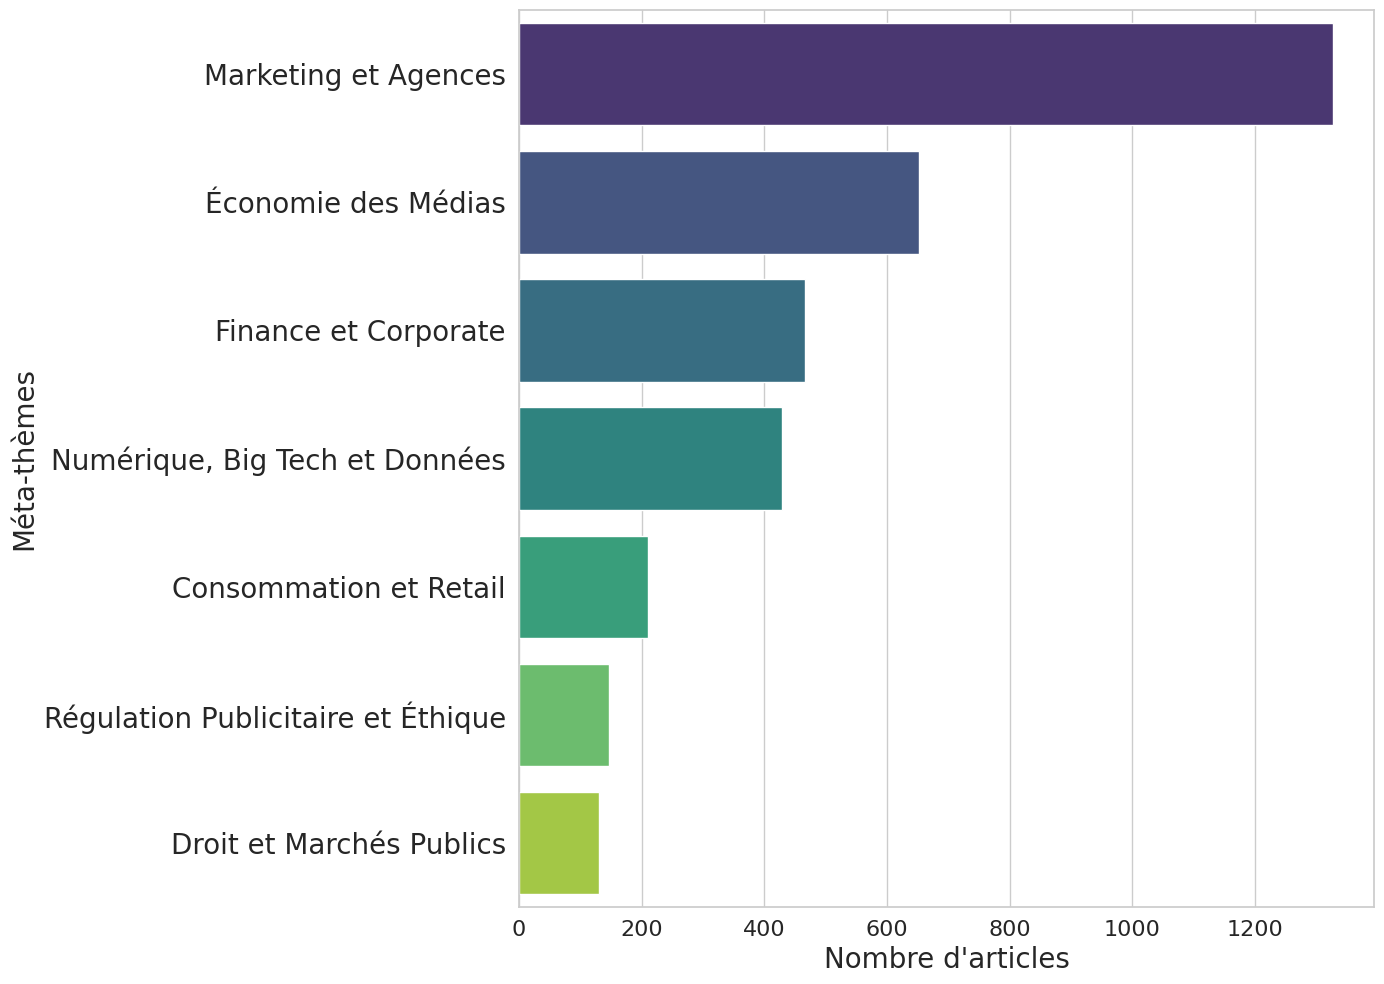

In [ ]:
# PLOT 2: THEMATIC ANALYSIS (Output File 2)
plt.figure(figsize=(14, 10))

# Prepare translated data for visualization
# Sum binary indicators to get total article counts per topic, sorted descending
counts = df_plot[topics].sum().sort_values(ascending=False)
df_counts = counts.reset_index()
df_counts.columns = ['Pôle', 'Total']
# Map raw topic keys to their clean English/French translated names
df_counts['Pôle'] = df_counts['Pôle'].map(translations)

# Generate the horizontal barplot
ax_d = sns.barplot(data=df_counts, x='Total', y='Pôle', palette="viridis")

# FONT SIZE ADJUSTMENTS (Increased for maximum readability of theme labels)
ax_d.set_xlabel("Number of Articles", fontsize=20)
ax_d.set_ylabel("Meta-themes", fontsize=20)

# Specifically target the y-axis (theme names) and x-axis ticks for larger sizing
plt.yticks(fontsize=20)
plt.xticks(fontsize=16)

# Final layout adjustment and high-resolution PDF export
plt.tight_layout()
plt.savefig("main_thematic_analysis.pdf", dpi=150)
plt.show()

## 3. Statistical Modeling

In [ ]:
# Explicitly define reference categories within the formula
# Treatment(reference='...') sets the baseline for comparison
for topic in topics:
    # Formula using the interaction operator (*)
    # This automatically includes: main effect (gender) + main effect (type) + interaction term (gender * type)
    formula = (
        f"{topic} ~ C(genre_assigned, Treatment(reference='M')) * "
        f"C(type, Treatment(reference='Générale'))"
    )

    try:
        # Fit the Logistic Regression model
        # disp=0 hides the convergence messages for a cleaner output
        model = smf.logit(formula, data=df).fit(disp=0)

        print(f"\n{'='*80}")
        print(f" INTERACTION ANALYSIS: {topic}")
        print(f"{'='*80}")

        # Display the full regression summary
        # This includes coefficients, p-values (P>|z|), and confidence intervals
        summary = model.summary()
        print(summary)

    except Exception as e:
        print(f"Error processing topic '{topic}': {e}")


 ANALYSE D'INTERACTION : Digital_BigTech_Data
                            Logit Regression Results                            
Dep. Variable:     Digital_BigTech_Data   No. Observations:                 3246
Model:                            Logit   Df Residuals:                     3240
Method:                             MLE   Df Model:                            5
Date:                  Sun, 25 Jan 2026   Pseudo R-squ.:                 0.08306
Time:                          15:58:39   Log-Likelihood:                -1162.2
converged:                         True   LL-Null:                       -1267.5
Covariance Type:              nonrobust   LLR p-value:                 1.573e-43
                                                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------------